# Setup

In [1]:
# ================================
# Imports
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib as mpl
from matplotlib.lines import Line2D

# Optional: nicer plots for papers
sns.set(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (3.5, 2.6)
plt.rcParams["savefig.dpi"] = 300

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# ================================
# Load Benchmark Data
# ================================

# Adjust path if needed
csv_path = "benchmark_results_consolidated.csv"

df = pd.read_csv(csv_path)

# ================================
# Basic Sanity Checks
# ================================

print("Dataset loaded successfully.\n")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nPreview:")
display(df)

Dataset loaded successfully.

Shape: (56, 13)

Columns:
['run', 'algorithm', 'n', 'parallel', 'omp_threads', 'poly_modulus_degree', 'num_primes', 'coeff_modulus_bits', 'key_gen_ms', 'sort_time_ms', 'ct_ct_multiplications', 'min_noise_budget_bits', 'correct']

Preview:


,run,algorithm,n,parallel,omp_threads,poly_modulus_degree,num_primes,coeff_modulus_bits,key_gen_ms,sort_time_ms,ct_ct_multiplications,min_noise_budget_bits,correct
0,2,Bitonic,2,False,1,32768,40,2400,3116,51223,27,2107,True
1,2,Bitonic,4,False,1,32768,40,2400,3116,307144,162,1666,True
2,2,Bitonic,8,False,1,32768,40,2400,3116,1226764,648,1007,True
3,2,Bitonic,16,False,1,32768,40,2400,3116,4098666,2160,119,True
4,2,Bitonic,2,True,8,32768,40,2400,3162,52267,27,2107,True
5,2,Bitonic,4,True,8,32768,40,2400,3162,155437,162,1664,True
6,2,Bitonic,8,True,8,32768,40,2400,3162,328970,648,1009,True
7,2,Bitonic,16,True,8,32768,40,2400,3162,968571,2160,123,True
8,2,Rank,2,False,1,16384,12,720,152,6468,63,237,True
9,2,Rank,4,False,1,16384,12,720,152,31379,306,234,True


# Visualizations

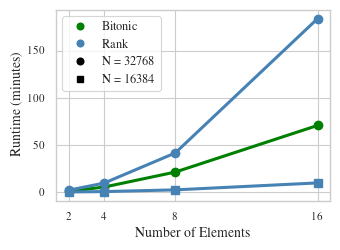

In [2]:
# ============================================
# Sequential Runtime Scaling (Custom Markers)
# ============================================

df_seq = df[df["parallel"] == False].copy()

stats = (
    df_seq.groupby(["algorithm", "poly_modulus_degree", "n"])["sort_time_ms"]
          .mean()
          .reset_index()
)

stats["runtime_min"] = stats["sort_time_ms"] / 1000.0 / 60.0

color_map = {
    "Bitonic": "green",
    "Rank": "steelblue"
}


for (algo, N), sub in stats.groupby(["algorithm", "poly_modulus_degree"]):
    
    # Only Rank with N=16384 gets square
    if algo == "Rank" and N == 16384:
        marker = "s"
    else:
        marker = "o"
    
    plt.plot(
        sub["n"],
        sub["runtime_min"],
        color=color_map.get(algo, "black"),
        marker=marker,
        linestyle="-",
        linewidth=2.2,
        markersize=6
    )

plt.xlabel("Number of Elements")
plt.ylabel("Runtime (minutes)")

plt.xticks([2, 4, 8, 16])

legend_elements = [
    # Algorithm (color)
    Line2D([0], [0], marker='o', color='green', linestyle='None', label='Bitonic'),
    Line2D([0], [0], marker='o', color='steelblue', linestyle='None', label='Rank'),

    # Modulus degree (order switched)
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='N = 32768'),
    Line2D([0], [0], marker='s', color='black', linestyle='None', label='N = 16384'),
]

plt.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.savefig("plots/sequential_runtime_scaling.pdf", dpi=300, bbox_inches="tight")
plt.show()

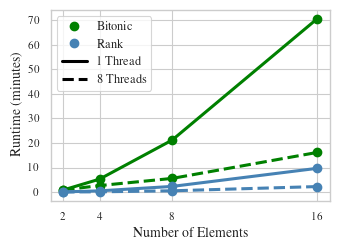

In [3]:
# ============================================
# Runtime Scaling (Optimal Parameters Only)
# ============================================

# Keep only optimal parameter choices
df_opt = df[
    ((df["algorithm"] == "Bitonic") & (df["poly_modulus_degree"] == 32768) & ((df["omp_threads"] == 1) | (df["omp_threads"] == 8))) |
    ((df["algorithm"] == "Rank") & (df["poly_modulus_degree"] == 16384) & ((df["omp_threads"] == 1) | (df["omp_threads"] == 8)))
].copy()

grouped = (
    df_opt.groupby(["algorithm", "parallel", "n"])["sort_time_ms"]
          .mean()
          .reset_index()
)

grouped["runtime_min"] = grouped["sort_time_ms"] / 1000.0 / 60.0

color_map = {
    "Bitonic": "green",
    "Rank": "steelblue"
}

for (algo, par), sub in grouped.groupby(["algorithm", "parallel"]):

    linestyle = "-" if not par else "--"

    plt.plot(
        sub["n"],
        sub["runtime_min"],
        color=color_map.get(algo, "black"),
        linestyle=linestyle,
        marker="o",
        linewidth=2.2,
        markersize=6
    )

plt.xlabel("Number of Elements")
plt.ylabel("Runtime (minutes)")
plt.xticks([2, 4, 8, 16])

from matplotlib.lines import Line2D

legend_elements = [
    # Algorithm (color)
    Line2D([0], [0], marker='o', color='green', linestyle='None',
           markersize=6, label='Bitonic'),
    Line2D([0], [0], marker='o', color='steelblue', linestyle='None',
           markersize=6, label='Rank'),

    # Execution mode (linestyle)
    Line2D([0], [0], color='black', linestyle='-', linewidth=2.2,
           label='1 Thread'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2,
           label='8 Threads'),
]

plt.legend(handles=legend_elements, loc="upper left")
plt.tight_layout()
plt.savefig("plots/runtime_scaling_optimal.pdf", dpi=300, bbox_inches="tight")
plt.show()

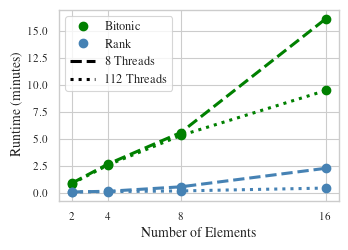

In [4]:
# ============================================
# Runtime Scaling (Optimal Parameters, 8 vs 112 Threads)
# ============================================

# Keep only optimal parameter choices
df_opt = df[
    ((df["algorithm"] == "Bitonic") & (df["poly_modulus_degree"] == 32768) & ((df["omp_threads"] == 8) | (df["omp_threads"] == 112))) |
    ((df["algorithm"] == "Rank") & (df["poly_modulus_degree"] == 16384) & ((df["omp_threads"] == 8) | (df["omp_threads"] == 112)))
].copy()

grouped = (
    df_opt.groupby(["algorithm", "omp_threads", "n"])["sort_time_ms"]
          .mean()
          .reset_index()
)

grouped["runtime_min"] = grouped["sort_time_ms"] / 1000.0 / 60.0

color_map = {
    "Bitonic": "green",
    "Rank": "steelblue"
}

linestyle_map = {
    8: "--",
    112: ":"
}

for (algo, threads), sub in grouped.groupby(["algorithm", "omp_threads"]):

    sub = sub.sort_values("n")

    plt.plot(
        sub["n"],
        sub["runtime_min"],
        color=color_map.get(algo, "black"),
        linestyle=linestyle_map[threads], 
        marker="o",
        linewidth=2.2,
        markersize=6
    )

plt.xlabel("Number of Elements")
plt.ylabel("Runtime (minutes)")
plt.xticks([2, 4, 8, 16])

legend_elements = [
    # Algorithm (color)
    Line2D([0], [0], marker='o', color='green', linestyle='None',
           markersize=6, label='Bitonic'),
    Line2D([0], [0], marker='o', color='steelblue', linestyle='None',
           markersize=6, label='Rank'),

    # Thread comparison
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2,
           label='8 Threads'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=2.2,
           label='112 Threads'),
]

plt.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig("plots/runtime_scaling_optimal_8_vs_112.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ============================================
# Speedup Table (Relative to 1 Thread)
# ============================================

# Keep optimal parameter choices INCLUDING 1, 8, 112 threads
df_speed = df[
    ((df["algorithm"] == "Bitonic") & (df["poly_modulus_degree"] == 32768)) |
    ((df["algorithm"] == "Rank") & (df["poly_modulus_degree"] == 16384))
].copy()

df_speed = df_speed[df_speed["omp_threads"].isin([1, 8, 112])]

grouped = (
    df_speed.groupby(["algorithm", "omp_threads", "n"])["sort_time_ms"]
            .mean()
            .reset_index()
)

# Pivot for easier speedup computation
pivot = grouped.pivot_table(
    index=["algorithm", "n"],
    columns="omp_threads",
    values="sort_time_ms"
)

# Compute speedups
pivot["speedup_8"] = pivot[1] / pivot[8]
pivot["speedup_112"] = pivot[1] / pivot[112]

# Keep only speedup columns
speedup_table = pivot[["speedup_8", "speedup_112"]].reset_index()

speedup_table["efficiency_8"] = speedup_table["speedup_8"] / 8
speedup_table["efficiency_112"] = speedup_table["speedup_112"] / 112

speedup_table

omp_threads,algorithm,n,speedup_8,speedup_112,efficiency_8,efficiency_112
0,Bitonic,2,0.990210,1.039106,0.123776,0.009278
1,Bitonic,4,1.977451,2.047030,0.247181,0.018277
2,Bitonic,8,3.786302,3.977186,0.473288,0.035511
3,Bitonic,16,4.363430,7.424275,0.545429,0.066288
4,Rank,2,1.361985,1.396934,0.170248,0.012473
5,Rank,4,3.724971,4.745783,0.465621,0.042373
6,Rank,8,4.198609,13.417686,0.524826,0.119801
7,Rank,16,4.256674,21.956125,0.532084,0.196037


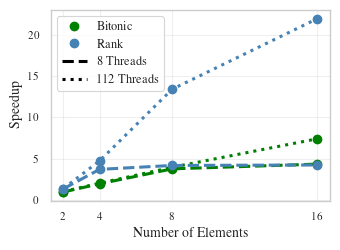

In [6]:
# ============================================
# Speedup vs Input Size (8 vs 112 Threads)
# ============================================

# Keep optimal parameter choices including 1, 8, 112 threads
df_speed = df[
    ((df["algorithm"] == "Bitonic") & (df["poly_modulus_degree"] == 32768)) |
    ((df["algorithm"] == "Rank") & (df["poly_modulus_degree"] == 16384))
].copy()

df_speed = df_speed[df_speed["omp_threads"].isin([1, 8, 112])]

grouped = (
    df_speed.groupby(["algorithm", "omp_threads", "n"])["sort_time_ms"]
            .mean()
            .reset_index()
)

pivot = grouped.pivot_table(
    index=["algorithm", "n"],
    columns="omp_threads",
    values="sort_time_ms"
)

pivot["speedup_8"] = pivot[1] / pivot[8]
pivot["speedup_112"] = pivot[1] / pivot[112]

speedup = pivot.reset_index()

color_map = {
    "Bitonic": "green",
    "Rank": "steelblue"
}

linestyle_map = {
    "speedup_8": "--",
    "speedup_112": ":"
}

for algo in speedup["algorithm"].unique():
    sub = speedup[speedup["algorithm"] == algo]

    for col in ["speedup_8", "speedup_112"]:
        plt.plot(
            sub["n"],
            sub[col],
            color=color_map[algo],
            linestyle=linestyle_map[col],
            marker="o",
            linewidth=2.2,
            markersize=6
        )

plt.xlabel("Number of Elements")
plt.ylabel("Speedup")
plt.xticks([2, 4, 8, 16])
plt.grid(alpha=0.3)

legend_elements = [
    Line2D([0], [0], marker='o', color='green', linestyle='None',
           markersize=6, label='Bitonic'),
    Line2D([0], [0], marker='o', color='steelblue', linestyle='None',
           markersize=6, label='Rank'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2,
           label='8 Threads'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=2.2,
           label='112 Threads'),
]

plt.legend(handles=legend_elements, loc="upper left")

plt.tight_layout()
plt.savefig("plots/speedup_8_vs_112.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ============================================
# Ciphertext-Ciphertext Multiplication Table
# ============================================

mults = (
    df.groupby(["algorithm", "n"])["ct_ct_multiplications"]
      .mean()
      .reset_index()
)

# Pivot to wide format (cleaner table)
mult_table = mults.pivot(
    index="n",
    columns="algorithm",
    values="ct_ct_multiplications"
).reset_index()

mult_table

algorithm,n,Bitonic,Rank
0,2,27.0,63.0
1,4,162.0,306.0
2,8,648.0,1332.0
3,16,2160.0,5544.0


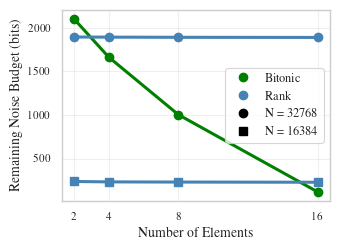

In [8]:
# ============================================
# Noise Budget by Polynomial Modulus Degree
# ============================================

noise_col = "min_noise_budget_bits" if "min_noise_budget_bits" in df.columns else "noise_budget_bits"

df_noise = df[
    ((df["algorithm"] == "Bitonic") & (df["poly_modulus_degree"] == 32768)) |
    ((df["algorithm"] == "Rank") & (df["poly_modulus_degree"].isin([16384, 32768])))
]

# Aggregate mean noise (threads averaged out)
noise_stats = (
    df_noise.groupby(["algorithm", "poly_modulus_degree", "n"])[noise_col]
      .mean()
      .reset_index()
)

color_map = {
    "Bitonic": "green",
    "Rank": "steelblue"
}

marker_map = {
    32768: "o",   # circle (high degree)
    16384: "s"    # square (low degree)
}

for (algo, degree), sub in noise_stats.groupby(["algorithm", "poly_modulus_degree"]):
    sub = sub.sort_values("n")

    plt.plot(
        sub["n"],
        sub[noise_col],
        marker=marker_map[degree],
        linewidth=2.2,
        markersize=6,
        color=color_map[algo]
    )

plt.xlabel("Number of Elements")
plt.ylabel("Remaining Noise Budget (bits)")
plt.xticks([2, 4, 8, 16])
plt.grid(alpha=0.3)

# -------------------------
# Custom Legend
# -------------------------

legend_elements = [
    # Algorithm (color)
    Line2D([0], [0], marker='o', color='green', linestyle='None',
           markersize=6, label='Bitonic'),
    Line2D([0], [0], marker='o', color='steelblue', linestyle='None',
           markersize=6, label='Rank'),

    # Degree (marker shape)
    Line2D([0], [0], marker='o', color='black', linestyle='None',
           markersize=6, label='N = 32768'),
    Line2D([0], [0], marker='s', color='black', linestyle='None',
           markersize=6, label='N = 16384'),
]

plt.legend(handles=legend_elements, loc="center right")

plt.tight_layout()
plt.savefig("plots/noise_budget_by_degree.pdf",
            dpi=300, bbox_inches="tight")
plt.show()